# Напишите заголовок проекта здесь

- Автор: Потапова Дарья
- Дата: 15.04.26

### Цели и задачи проекта

**Цель проекта** - провести исследовательский анализ рынка заведений общественного питания в Москве.

**Задачи проекта**:
1. Загрузить данные, изучить их объём и соответствуе описанию.
2. Выполнить их предобработку к исследовательскому анализу.
3. Провести исследовательский анализ данных и ответить на следующие вопросы, сопроводив их визуализацией результатов:
   - Какие категории заведений представлены в данных?
   - Какие административные районы Москвы присутствуют в данных?
   - Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми?
   - Сильно ли различаются усреднённые рейтинги для разных типов общепита?
   - С какими данными показывают самую сильную корреляцию рейтинги заведений?
   - К какой категории заведений относятся топ-15 популярных сетей в Москве?
   - Как удалённость от центра влияет на цены в заведениях?
4. Сформулировать выводы по проведённому анализу.

### Описание данных

Файл /datasets/rest_info.csv содержит информацию о заведениях общественного питания:
- `name` — название заведения;
- `address` — адрес заведения;
- `district` — административный район, в котором находится заведение, например Центральный административный округ;
- `category` — категория заведения, например «кафе», «пиццерия» или «кофейня»;
- `hours` — информация о днях и часах работы;
- `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- `chain` — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):
   - 0 — заведение не является сетевым;
   - 1 — заведение является сетевым.
- `seats` — количество посадочных мест.


Файл /datasets/rest_price.csv содержит информацию о среднем чеке в заведениях общественного питания:
- `price` — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
- `avg_bill` — строка, которая хранит среднюю стоимость заказа в виде диапазона, например:
   - «Средний счёт: 1000–1500 ₽»;
   - «Цена чашки капучино: 130–220 ₽»;
   - «Цена бокала пива: 400–600 ₽».
и так далее;
- `middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца `avg_bill`, начинающихся с подстроки «Средний счёт»:
   - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
   - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
   - Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.
- `middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца `avg_bill`, начинающихся с подстроки «Цена одной чашки капучино»:
   - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
   - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
   - Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.

### Содержимое проекта

Основные шаги выполнения проекта:

1. Загрузка данных и знакомтво с ними.
2. Проверка ошибок в данных и их предобработка. Шаг включает проверку ошибок в названиях, а также проверку типов данных, наличия пропусков и дубликатов.
3. Исследовательский анализ данных с визуализацией результатов.
4. Выводы по проведённому анализу.

## 1. Загрузка данных и знакомство с ними

Начнём с загрузки библиотек и датасетов `rest_info` и `rest_price`. Будем использовать pandas и библиотеки визуализации данных matplotlib и seaborn, а также phik для построения матрицы корреляции. Данные датасетов сохраним в двух переменных: `rest_info` и `rest_price`.

In [ ]:
!pip install phik

In [ ]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix

In [ ]:
# Выгружаем данные в переменные rest_info и rest_price
rest_info = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
rest_price = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

Познакомимся с данными датасета `rest_info.csv` — выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [ ]:
# Выводим первые строки датафрейма
rest_info.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [ ]:
# Выводим информацию о датафрейме
rest_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


Датасет rest_info.csv содержит 9 столбцов и 8406 строк, в которых представлена информация о заведениях общественного питания в Москве.

После первичного анализа данных можно сделать слудующие выводы:
- Названия столбцов представлены в едином стиле.
- Значения в столбцах `id`, `name`, `category`, `address`, `district`, `hours` представлены в корректном для них типе данных *object*. Числовые значения хранятся в столбцах `rating` (*float64*), `chain` (*int64*), `seats` (*float64*). Для последнего столбца данные можно преобразовать к типу *int64* для уменьшения объема памяти, так как посадочные места обозначаются целыми числами.
- Пропуски содержатся только в столбцах `hours` и `seats`. Однако следует проверить и другие столбцы: в них могут встречаться значения-индикаторы, которые будут говорить об отсутствии данных.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.



Теперь познакомимся с данными датасета `rest_price.csv`.

In [ ]:
# Выводим первые строки датафрейма
rest_price.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [ ]:
# Выводим информацию о датафрейме
rest_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


Датасет rest_info.csv содержит 5 столбцов и 4058 строк, в которых представлена информация о ценах в заведениях общественного питания в Москве.

После первичного анализа данных можно сделать слудующие выводы:
- Названия столбцов представлены в едином стиле.
- Значения в столбцах `id`, `price`, `avg_bill` представлены в корректном для них типе данных *object*. Числовые значения хранятся в столбцах `middle_avg_bill`, `middle_coffee_cup` и представлены типом *float64*.
- Пропуски содержатся в столбцах `price`, `avg_bill`, `middle_avg_bill` и `middle_coffee_cup`, то есть во всех столбцах кроме индекса `id`. Пропуски в двух последних столбцах связаны с методом их заполнения, другие пропуски необходимо проверить.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.


---

### Промежуточный вывод

О полученных данных можно сделать следующий промежуточный вывод: объем данных в датасетах не совпадает, а значит более чем для половины заведений информация о ценах отсутствует. Однако такая разница может быть связана и с большим количеством дубликатов - это необходимо проверить. Второй датасет содержит значительное количество пропусков, на что также стоит обратить внимание. Типы данных соответствуют значениям, которые хранятся в столбцах, названия столбцов привдены к единому типу и соответствуют описанию.

### Подготовка единого датафрейма

Объединим данные двух датасетов в один, с которым продолжим работу.

In [ ]:
# Соединяем данные в единый датафрейм df
df = rest_info.merge(rest_price, on='id', how='left')

In [ ]:
# Выводим информацию о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 853.9+ KB


In [ ]:
# Создадим копию датафрейма
tmp = df.copy()

## 2. Предобработка данных

Подготовим данные к исследовательскому анализу.

Названия столбцов приведены к стилю snake_case, поэтому оставим их без изменений.


In [ ]:
# Выведем названия столбцов датафрейма df
df.columns

Index(['id', 'name', 'category', 'address', 'district', 'hours', 'rating',
       'chain', 'seats', 'price', 'avg_bill', 'middle_avg_bill',
       'middle_coffee_cup'],
      dtype='object')

Выведем типы данных, которые содержит в себе датафрейм.

In [ ]:
# Выведем типы данных датафрейма
df.dtypes

,0
id,object
name,object
category,object
address,object
district,object
hours,object
rating,float64
chain,int64
seats,float64
price,object


Заменим тип данных в столбце `seats` уже на этапе обработки пропусков, так как количество посадочных мест - целочисленный показатель, и чтобы корректно привести данные к этому типу, необходимо обработать пропуски. Стобец `chain` по описанию хранит значения 0 или 1, проверим это и проведем оптимизацию размерности целочисленного типа с помощью метода `to_numeric()`. Данные в других столбцах представлены в корректном типе.

In [ ]:
# Выведем уникальные значения столбца chain
df['chain'].unique()

array([0, 1])

In [ ]:
# Оптимизируем целочисленный тип данных в датафрейме
df['chain'] = pd.to_numeric(df['chain'], downcast='integer')

In [ ]:
# Проверим измененные типы данных
df.dtypes

,0
id,object
name,object
category,object
address,object
district,object
hours,object
rating,float64
chain,int8
seats,float64
price,object


Изучим пропущенные значения в данных: посчитаем их количество в каждом столбце датафрейма в абсолютном и относительном значении для их дальнейшей обработки.

In [ ]:
# Выведем количество пропусков в каждом столбце
df.isna().sum()

,0
id,0
name,0
category,0
address,0
district,0
hours,536
rating,0
chain,0
seats,3611
price,5091


In [ ]:
# Выведем долю пропусков в каждом столбце
df.isna().sum() / df.shape[0]

,0
id,0.000000
name,0.000000
category,0.000000
address,0.000000
district,0.000000
hours,0.063764
rating,0.000000
chain,0.000000
seats,0.429574
price,0.605639


Минимальное количество пропусков содержит столбец `hours` (около 6%), максимальное - столбец `middle_coffee_cup` (около 94%). Пропуски в столбцах `hours`, `seats`, `price` и `avg_bill` в первую очередь могут быть связаны с отсутствием этой информации о представленном заведении. Разница в объемах исходным датафреймов также говорит об этом. Пропуски в столбцах `middle_avg_bill` и `middle_coffee_cup` связаны с методом их заполнения:

1. middle_avg_bill — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»:
    - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    - Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.
2. middle_coffee_cup — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино»:
    - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    - Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.

Таким образом, если значение будет начинаться со слов «Средний чек» или «Цена одной чашки кофе», значения не будут заполнены, так как учитываются только варианты «Средний счёт» и «Цена одной чашки капучино». Такие пропуски заменять и удалять не будем.

Удаление строк с обнаруженными пропусками приведет к сильному сокращению данных, поэтому лучшее решение - заменить их на значения-индикаторы. Для столбца `seats` введем значение-индикатор *-1*, для столбцов `hours`, `price` и `avg_bill` - *unknown*.

In [ ]:
# Заполняем пропуски
df['price'] = df['price'].fillna('unknown')
df['hours'] = df['hours'].fillna('unknown')
df['avg_bill'] = df['avg_bill'].fillna('unknown')
df['seats'] = df['seats'].fillna(-1)

Пропуски в столбце seats устранены, поэтому можем заменить тип данных.

In [ ]:
# Приводим столбец к целочисленному типу
df['seats'] = pd.to_numeric(df['seats'], downcast='integer')
df['seats'].dtype

dtype('int16')

In [ ]:
# Выведем количество пропусков после замены
df.isna().sum()

,0
id,0
name,0
category,0
address,0
district,0
hours,0
rating,0
chain,0
seats,0
price,0


Проверим данные на явные и неявные дубликаты. Рассмотрим поля с текстовыми значениями. Для оптимизации проверки нормализуем данные в текстовых столбцах, приведя их к нижнему регистру.

In [ ]:
# Приведемданные в текстовых столбцах к нижнему регистру
for column in ['name','category','address', 'district', 'hours', 'price', 'avg_bill']:
    df[column] = df[column].str.lower()

In [ ]:
ids = {'ул.': 'улица', 'пр.': 'проспект', 'ш.': 'шоссе', 'б-р': 'бульвар'}
for old, new in ids.items():
  df['address'] = df['address'].str.replace(old, new)

Найдем дубликаты по названию и адресу. Такие дубликаты могут быть связаны не только с ошибкой, но и с повторным внесением заведения в таблицу с новым временем работы, средним чеком или измененной категорией в связи с возможным расширением. При удалении оставим последнее вхождение в таблицу.

In [ ]:
# Отсортируем датафрейм
df_sorted = df.sort_values(by=df.columns.tolist())

# Найдем и выведем дубликаты
duplicates = df_sorted[df_sorted[['name','address']].duplicated(keep=False)]
print("Дублирующиеся строки:")
duplicates

Дублирующиеся строки:


,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
189,072032ce16dc47bfbc63b672c75bd371,кафе,кафе,"москва, парк ангарские пруды",северный административный округ,"ежедневно, 09:00–23:00",3.2,0,-1,unknown,unknown,NaN,NaN
3091,3c2a73ea79a04be48858fab3685f2f37,хлеб да выпечка,булочная,"москва, ярцевская улица, 19",западный административный округ,"ежедневно, 09:00–22:00",4.1,1,276,unknown,unknown,NaN,NaN
1430,62608690e9cc464fbcd980cfd552e334,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",северный административный округ,"ежедневно, 09:00–21:00",4.2,0,188,unknown,unknown,NaN,NaN
215,897ddbc6746c4388b19dc8a9fcdbb488,кафе,кафе,"москва, парк ангарские пруды",северный административный округ,"ежедневно, 10:00–22:00",3.2,0,-1,unknown,unknown,NaN,NaN
1511,a69f018d5c064873a3b491b0121bc1b4,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,1,188,unknown,unknown,NaN,NaN
2420,aba1de7ad7d64ac0a3f8684bda29d905,раковарня клешни и хвосты,"бар,паб","москва, проспект мира, 118",северо-восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,1,150,unknown,unknown,NaN,NaN
2211,c6ef39ae8a8c483d8f9a6531bc386a2c,раковарня клешни и хвосты,ресторан,"москва, проспект мира, 118",северо-восточный административный округ,"ежедневно, 12:00–00:00",4.4,0,150,unknown,unknown,NaN,NaN
3109,d3116844e4e048f99614eb30be3214e0,хлеб да выпечка,кафе,"москва, ярцевская улица, 19",западный административный округ,unknown,4.1,0,276,unknown,unknown,NaN,NaN


In [ ]:
# Удалим дубликаты
df = df_sorted.drop_duplicates(subset=['name','address'], keep='last').copy()

In [ ]:
print(f"Количество строк исходного датафрейма: {tmp.shape[0]}")
print(f"Количество строк датафрейма после удаления дубликатов: {df.shape[0]}")

Количество строк исходного датафрейма: 8406
Количество строк датафрейма после удаления дубликатов: 8402


Для дальнейшей работы создадим столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [ ]:
# Проверим в каком виде встречается запись "ежедневно и круглосуточно"
print(df[df["hours"].str.startswith(('ежедневно', 'каждый'))]['hours'].unique())


['ежедневно, круглосуточно' 'ежедневно, 11:00–00:00'
 'ежедневно, 09:00–22:00' 'ежедневно, 09:00–23:00'
 'ежедневно, 07:00–23:00' 'ежедневно, 11:00–23:00'
 'ежедневно, 06:30–18:30' 'ежедневно, 10:00–00:00'
 'ежедневно, 08:00–21:00' 'ежедневно, 07:30–22:00'
 'ежедневно, 10:00–21:00' 'ежедневно, 12:00–00:00'
 'ежедневно, 07:00–22:00' 'ежедневно, 12:00–21:00'
 'ежедневно, 05:00–02:00' 'ежедневно, 09:00–21:00'
 'ежедневно, 08:00–20:00' 'ежедневно, 10:00–22:00'
 'ежедневно, 10:00–23:00' 'ежедневно, 09:00–20:00'
 'ежедневно, 09:30–23:00' 'ежедневно, 12:00–23:00'
 'ежедневно, 08:00–23:00' 'ежедневно, 09:00–02:00'
 'ежедневно, 08:00–18:00' 'ежедневно, 08:00–22:00'
 'ежедневно, 10:00–20:00' 'ежедневно, 12:00–22:00'
 'ежедневно, 08:30–21:30' 'ежедневно, 12:00–23:30'
 'ежедневно, 08:30–20:00' 'ежедневно, 11:00–23:30'
 'ежедневно, 11:00–01:00' 'ежедневно, 07:00–02:00'
 'ежедневно, 09:00–01:00' 'ежедневно, 10:00–18:00'
 'ежедневно, 10:30–21:30' 'ежедневно, 13:00–04:00'
 'ежедневно, 11:00–22:00' 'еж

In [ ]:
# Создадим новый столбец
df['is_24_7'] = df['hours'].apply(lambda x: True if x == 'ежедневно, круглосуточно' else False)

In [ ]:
# Выведем информацию о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8402 entries, 61 to 1634
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8402 non-null   object 
 1   name               8402 non-null   object 
 2   category           8402 non-null   object 
 3   address            8402 non-null   object 
 4   district           8402 non-null   object 
 5   hours              8402 non-null   object 
 6   rating             8402 non-null   float64
 7   chain              8402 non-null   int8   
 8   seats              8402 non-null   int16  
 9   price              8402 non-null   object 
 10  avg_bill           8402 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
 13  is_24_7            8402 non-null   bool   
dtypes: bool(1), float64(3), int16(1), int8(1), object(8)
memory usage: 820.5+ KB


---

### Промежуточный вывод

В результате предобработки данных были преобразованы и оптимизированы числовые типы данных, а также проанализированы пропуски и дубликаты. В качестве устранения пропусков для столбца `seats` было введено значение-индикатор *-1*, для столбцов `hours`, `price` и `avg_bill` - *unknown*, пропуски в столбцах `middle_avg_bill`, `middle_coffee_cup` оставлены без изменений. При анализе содержимого строк было выявдено 4 дубликата заведений по ключу имя-адрес. Дубликаты были удалены с сохранением последнего значения. Доля удаленных строк составила менее 0,05%. Также был создадан столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7.

In [ ]:
print(f"Количество строк исходного датафрейма: {tmp.shape[0]}")
print(f"Количество строк датафрейма после удаления дубликатов: {df.shape[0]}")
print(f"Доля удаленных строк: {(tmp.shape[0] - df.shape[0]) / tmp.shape[0]}")

Количество строк исходного датафрейма: 8406
Количество строк датафрейма после удаления дубликатов: 8402
Доля удаленных строк: 0.0004758505829169641


## 3. Исследовательский анализ данных
Проведите исследовательский анализ исходных данных.

При исследовании данных используйте визуализации. Проверьте, что для каждого случая подобран оптимальный тип визуализации с корректным оформлением. У графика должен быть заголовок, понятные подписи по осям, при необходимости легенда, а его размер является оптимальным для изучения.

После исследования каждого пункта оставляйте небольшой комментарий с выводом или обсуждением результата. В конце шага обобщите результаты, выделив, по вашему мнению, самые важные.

---

### Задача 1

Какие категории заведений представлены в данных? Для ответа на поставленный вопрос найдем количество объектов общественного питания по каждой категории.

In [ ]:
print('Распределение заведений в зависимости от категории:')
pd.concat([df['category'].value_counts(), df['category'].value_counts(normalize=True)], axis=1)

Распределение заведений в зависимости от категории:


,count,proportion
category,,
кафе,2377,0.282909
ресторан,2042,0.243037
кофейня,1413,0.168174
"бар,паб",764,0.090931
пиццерия,633,0.075339
быстрое питание,603,0.071769
столовая,315,0.037491
булочная,255,0.030350


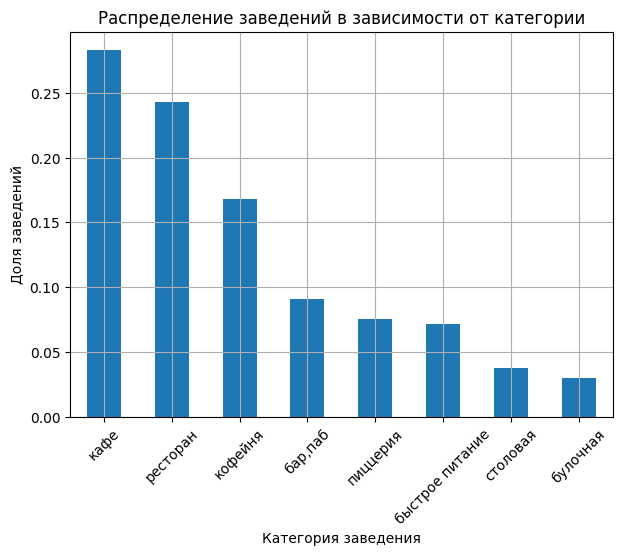

In [ ]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 5))

# Строим столбчатую диаграмму
df['category'].value_counts(normalize=True).plot(
               kind='bar', # Тип графика — столбчатая диаграмма
               rot=45, # Градус вращения подписи по оси Х
               legend=False,# Выключаем легенду
               title=f'Распределение заведений в зависимости от категории'
)

# Настраиваем оформление графика
plt.xlabel('Категория заведения')
plt.ylabel('Доля заведений')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

По выведенным данным и построенной столбчатой диаграмме можно сделать вывод о том, что наиболее популярная категория "Кафе" включает в себя более 28% завдений Москвы. Следующая по популярности категория - "Ресторан" (24%). Наименее популярные категории по численнояти - "Столовая" и "Булочная", их общая доля от всех заведений составляет менее 10%.

---

### Задача 2

Какие административные районы Москвы присутствуют в данных? Для ответа на поставленный вопрос исследуем распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы.

In [ ]:
print('Распределение заведений в зависимости от административного района:')
pd.concat([df['district'].value_counts(), df['district'].value_counts(normalize=True)], axis=1)

Распределение заведений в зависимости от административного района:


,count,proportion
district,,
центральный административный округ,2242,0.266841
северный административный округ,898,0.106879
южный административный округ,892,0.106165
северо-восточный административный округ,890,0.105927
западный административный округ,850,0.101166
восточный административный округ,798,0.094977
юго-восточный административный округ,714,0.084980
юго-западный административный округ,709,0.084385
северо-западный административный округ,409,0.048679


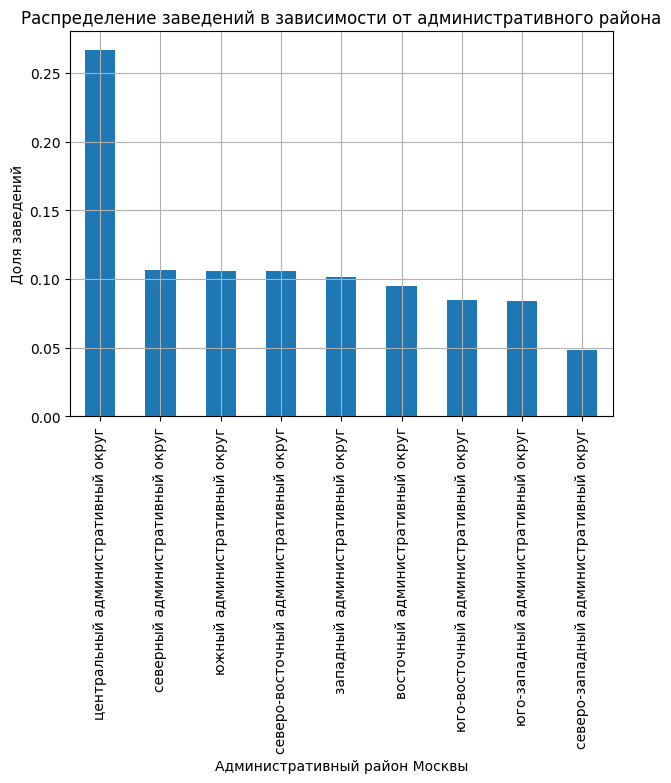

In [ ]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 5))

# Строим столбчатую диаграмму
df['district'].value_counts(normalize=True).plot(
               kind='bar', # Тип графика — столбчатая диаграмма
               rot=90, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Распределение заведений в зависимости от административного района'
)

# Настраиваем оформление графика
plt.xlabel('Административный район Москвы')
plt.ylabel('Доля заведений')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

По графику можно заметить, что Центарльный административный округ содержит в себе наибольшее количество заведений (около 27%). Распределение заведений по другим административным районам Москвы близко к равномерному - на каждый район приходится около 8-10% заведений. Отдельно можно также выделить Северо-Западный административный округ с нименьшей долей заведений - менее 5%.

In [ ]:
grouped = df[df['district'] == 'центральный административный округ'].groupby('category').agg(total_count=('category', 'count'))
print('Распределение заведений в зависимости от категории в Центральном округе:')
grouped

Распределение заведений в зависимости от категории в Центральном округе:


,total_count
category,
"бар,паб",364
булочная,50
быстрое питание,87
кафе,464
кофейня,428
пиццерия,113
ресторан,670
столовая,66


<Figure size 700x500 with 0 Axes>

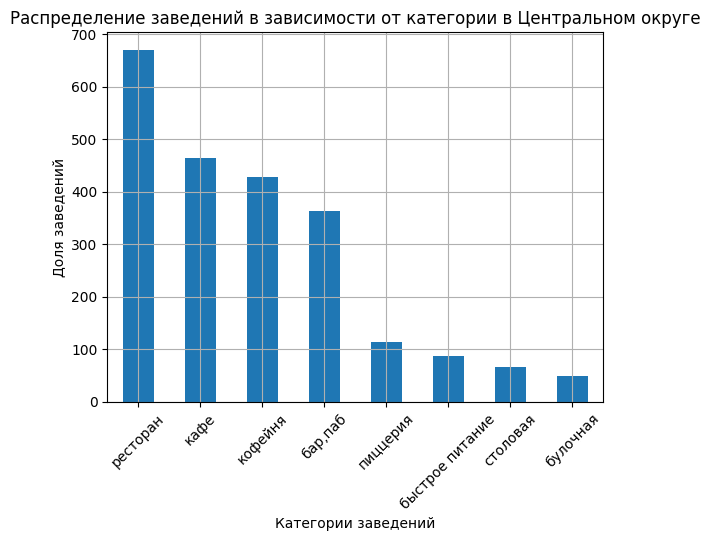

In [ ]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 5))

# Строим столбчатую диаграмму
grouped.sort_values(by='total_count', ascending=False).plot(
            kind='bar', # Тип графика — столбчатая диаграмма
            rot=45, # Градус вращения подписи по оси Х
            legend=False, # Выключаем легенду
            title=f'Распределение заведений в зависимости от категории в Центральном округе'
)

# Настраиваем оформление графика
plt.xlabel('Категории заведений')
plt.ylabel('Доля заведений')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Распределение заведений в зависимости от категории в Центральном административном округе Москвы показывает следующее: в отличие от общего распределения по категориям, в этом районе самый многочисленный тип заведений - рестораны (670 из 2242). Таким образом, можно сделать вывод о том, что основная доля ресторанов расположена именно в Центральном административном округе Москвы. Следующими по популярности категориями являются кафе и кофейни.



---

### Задача 3

Изучим соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми? Для ответа на поставленные вопросы исследуем, как распредены заведения в зависимости от их типа.

In [ ]:
print('Распределение заведений в зависимости от типа (1 - сетевые, 0 - несетевые)')
df['chain'].value_counts(normalize=True)

Распределение заведений в зависимости от типа (1 - сетевые, 0 - несетевые)


,proportion
chain,
0,0.618781
1,0.381219


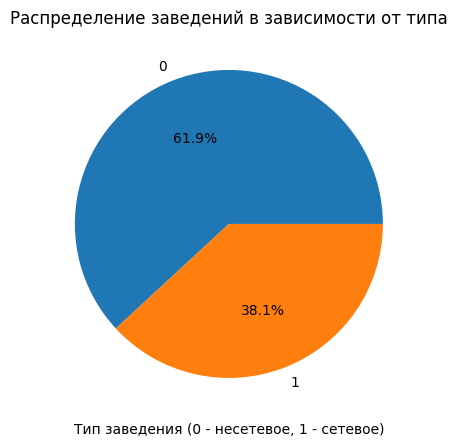

In [ ]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 5))

# Строим столбчатую диаграмму
df['chain'].value_counts(normalize=True).plot(
            kind='pie', # Тип графика — круговая диаграмма
            autopct='%1.1f%%',
            title=f'Распределение заведений в зависимости от типа'
)

# Настраиваем оформление графика
plt.xlabel('Тип заведения (0 - несетевое, 1 - сетевое)')
plt.ylabel('')

# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Столбчатая диаграмма показывает, что количество несетевых заведений превышает количество сетевых. Их процентное соотношение - 68% и 32%. Это может быть связано с тем, что наиболее многочисленные категории (кафе и рестораны) зачастую являются не сетевыми проектами.

In [ ]:
print('Распределение сетевых заведений в зависимости от их категории:')
df.groupby('category')['chain'].value_counts(normalize=True).unstack(fill_value=0)

Распределение сетевых заведений в зависимости от их категории:


chain,0,1
category,,
"бар,паб",0.780105,0.219895
булочная,0.388235,0.611765
быстрое питание,0.615257,0.384743
кафе,0.672276,0.327724
кофейня,0.490446,0.509554
пиццерия,0.478673,0.521327
ресторан,0.642507,0.357493
столовая,0.720635,0.279365


<Figure size 700x500 with 0 Axes>

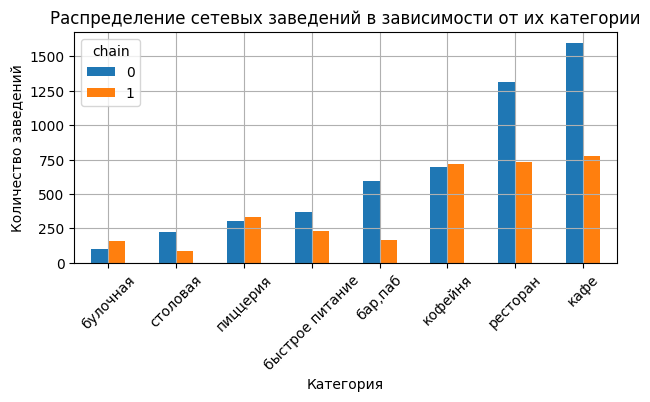

In [ ]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 5))

# Построим график столбчатой диаграммы
grouped = df.groupby('category')['chain'].value_counts().unstack(fill_value=0)
grouped.sort_values(by=[0, 1]).plot(kind='bar',
               title=f'Распределение сетевых заведений в зависимости от их категории',
               legend=True,
               ylabel='Количество заведений',
               xlabel='Категория',
               rot=45,
               figsize=(7, 3))

# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

По графику можно сделать следующий вывод:


*   Категории заведений, где количество сетевых заведений превышает количество несетевых - булочная, пиццерия, кофейня. Однако стоит заметить, что разрыв в числе заведений разного типа в этих категориях небольшой.
*   Категории заведений, где количество несетевых заведений превышает количество сетевых - бар, быстрое питание, ресторан, столовая.
*   Наибольшая разница в долях завдений разного типа прослеживается в категориях бар, кафе, столовая, ресторан.






---

### Задача 4

Исследуем количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Для ответа на поставленные вопросы исследуем, как распредены заведения в зависимости от количества посадочных мест, а также для каждой категории заведений найдем наиболее типичное для него количество посадочных мест.


In [ ]:
# Статистические показатели столбца seats
print('Статистические показатели столбца seats:')
df[df['seats'] != -1]['seats'].describe()

Статистические показатели столбца seats:


,seats
count,4792.000000
mean,108.361436
std,122.841130
min,0.000000
25%,40.000000
50%,75.000000
75%,140.000000
max,1288.000000


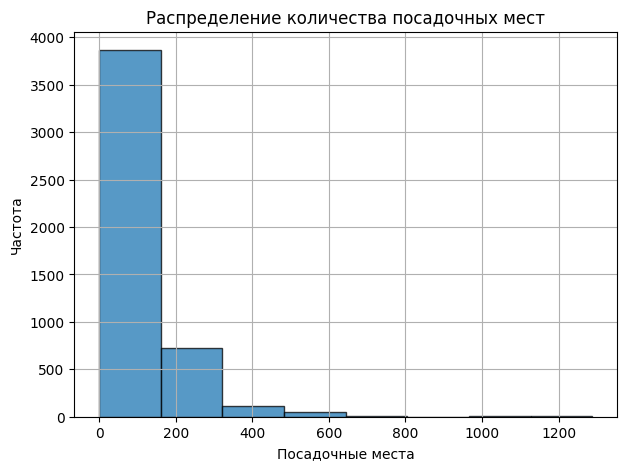

In [ ]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 5))

# Строим гистограмму
df[df['seats'] != -1]['seats'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=8, # Устанавливаем количество корзин
                alpha=0.75,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение количества посадочных мест')
plt.xlabel('Посадочные места')
plt.ylabel('Частота')

# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

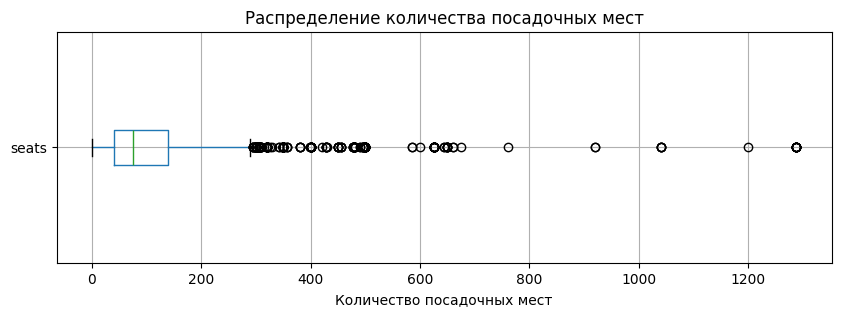

In [ ]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 3))

# Строим диаграмму размаха значений в столбце score
df[df['seats'] != -1].boxplot(column='seats', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение количества посадочных мест')
plt.xlabel('Количество посадочных мест')

# Выводим график
plt.show()

Распределение значения количества посадочных мест асимметричное и скошенное вправо. Медиана и среднее значение не совпадают. Минимальное количество посадочных мест - 0, это является корректным значением, так как кофейни могут не иметь посадочных мест и работать навынос. Максимальное количество - 1288, заведение такого масштаба может являться банкетным залом или ресторанным комплексом, однако такое значение может быть и ошибкой. Такие значения будем считать аномальными при медиане, равной 75. Для обзора выбросов была построена диаграмма размаха - значения больше 300 можно считать выбросами. Важно отметить, что значение индикатор -1, обозначающее отсутствие информации о количестве посадочных мест, в расчете и построении диаграмм не участвовало.

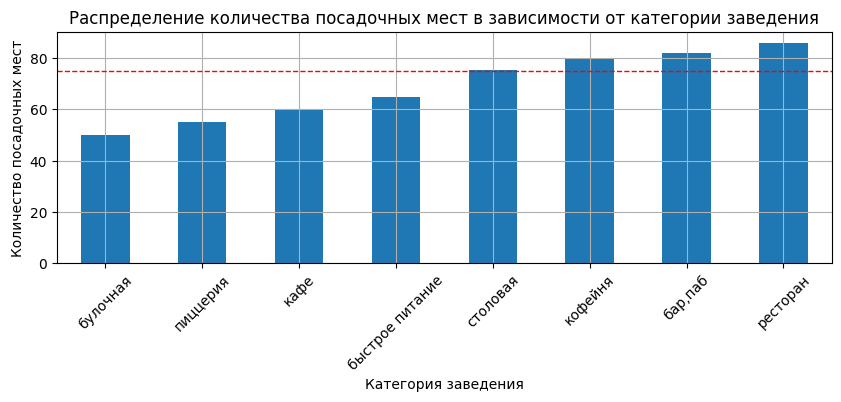

In [ ]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 3))

# Построим график столбчатой диаграммы
grouped = df[df['seats'] != -1].groupby('category')['seats'].median()
grouped.sort_values().plot(kind='bar',
               title=f'Распределение количества посадочных мест в зависимости от категории заведения',
               ylabel='Количество посадочных мест',
               xlabel='Категория заведения',
               rot=45
)

# Добавляем сетку графика
plt.grid()

# Добавляем линию с медианным зачением
seats_median = df[df['seats'] != -1]['seats'].median()
plt.axhline(seats_median, color='red',
                linestyle='--', linewidth=1,
                label=f'Значение по всем данным {round(seats_median, 4)}')

# Выводим график
plt.show()

Для отображения наиболее типичного для каждой категории количества посадочных мест использовалось медианное значение, которое менее чувствительно к выбросам. Распределение показывает, что в ресторанах, барах и кофейнях Москвы посадочных мест в среднем больше, чем в заведениях других категорий. Меньше всего посадочных мест, как правило, в булочных.

---

### Задача 5

Сильно ли различаются усреднённые рейтинги для разных типов общепита? Для ответа на поставленный вопрос исследуем рейтинг заведений и распределение средних рейтингов по категориям заведений.

In [ ]:
# Статистические показатели столбца rating
print('Статистические показатели столбца rating:')
df['rating'].describe()

Статистические показатели столбца rating:


,rating
count,8402.000000
mean,4.230017
std,0.470320
min,1.000000
25%,4.100000
50%,4.300000
75%,4.400000
max,5.000000


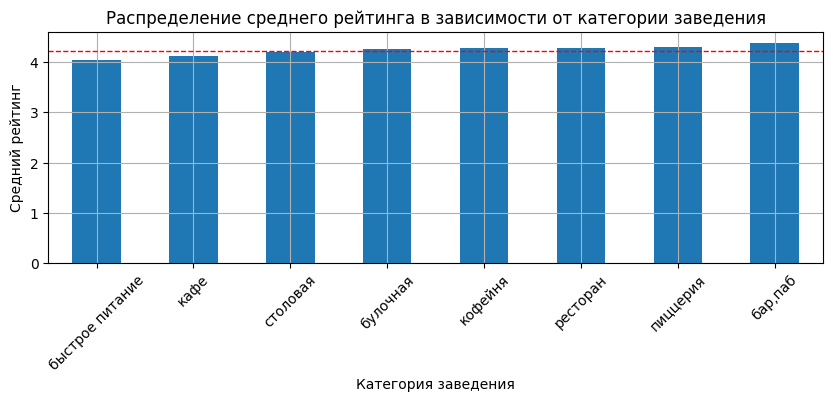

In [ ]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 3))

# Построим график столбчатой диаграммы
grouped = df.groupby('category')['rating'].mean()
grouped.sort_values().plot(kind='bar',
               title=f'Распределение среднего рейтинга в зависимости от категории заведения',
               ylabel='Средний рейтинг',
               xlabel='Категория заведения',
               rot=45
)

# Добавляем сетку графика
plt.grid()

# Добавляем линию со средним значением
mean_rating = df['rating'].mean()
plt.axhline(mean_rating, color='red',
                linestyle='--', linewidth=1,
                label=f'Значение по всем данным {round(mean_rating, 4)}')

# Выводим график
plt.show()

Столбец рейтинг не содержит некорректных значений (минимальное значение - 1, максимальное - 5). Среднее значение составляет 4,2. Распределение среднего рейтинга в зависимости от категории заведения показывает, что усреднённые рейтинги для разных типов общепита слабо отличаются друг от друга. Все категории обладают оценкой выше 4. Самый высокий усредненный рейтинг пренадлежит категории бар, самый низкий - быстрое питание.

---

### Задача 6

Изучим, с какими данными показывают самую сильную корреляцию рейтинги заведений. Построим матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным.

In [ ]:
# Вычисляем корреляционную матрицу с использованием phi_k
correlation_matrix = df[['category', 'district', 'chain', 'seats',
                         'price', 'is_24_7', 'rating']].phik_matrix()

# Выводим результат
print('Корреляционная матрица с коэффициентом phi_k для переменной rating:')
correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)

interval columns not set, guessing: ['chain', 'seats', 'rating']
Корреляционная матрица с коэффициентом phi_k для переменной rating:


,rating
price,0.281253
district,0.200761
category,0.189856
is_24_7,0.150365
chain,0.107677
seats,0.000000


Наибольшая корреляция рейтинга заведения наблюдается с ценовой категорией (`0.28`) и положением заведения (`0.20`). Для остальных признаков (категория, круглосуточная работа, статус сетевого заведения) коэффициент корреляции снижается с `0.19` до `0.11`. С количеством посадочных мест корреляции не наблюдается. Важно помнить, что `phi_k` сообщает только о наличии связи между данными - на характер связи коэффициент `phi_k` не указывает.

Перед тем как перейти к дальнейшему анализу, визуализируем результат корреляции с помощью тепловой карты и библиотеки seaborn:

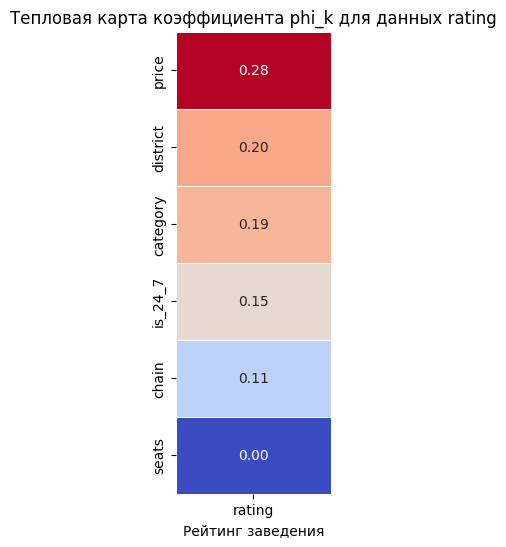

In [ ]:
# Строим тепловую карту
plt.figure(figsize=(2, 6))

# Сохраняем матрицу корреляции признака churn с другими признаками клиента
data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)
sns.heatmap(data_heatmap,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5,
            cbar=False
)

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта коэффициента phi_k для данных rating')
plt.xlabel('Рейтинг заведения')

# Выводим график
plt.show()

Рассмотрим, как меняется средний рейтинг в зависимости от ценовой категории.

In [ ]:
# Выведем все ценовые категории
df['price'].unique()

array(['средние', 'unknown', 'низкие', 'высокие', 'выше среднего'],
      dtype=object)

In [ ]:
print('Распределение рейтинга в зависимости от ценовой категории:')
df.groupby('price')['rating'].mean().sort_values()

Распределение рейтинга в зависимости от ценовой категории:


,rating
price,
unknown,4.166778
низкие,4.173077
средние,4.297874
выше среднего,4.386348
высокие,4.436611


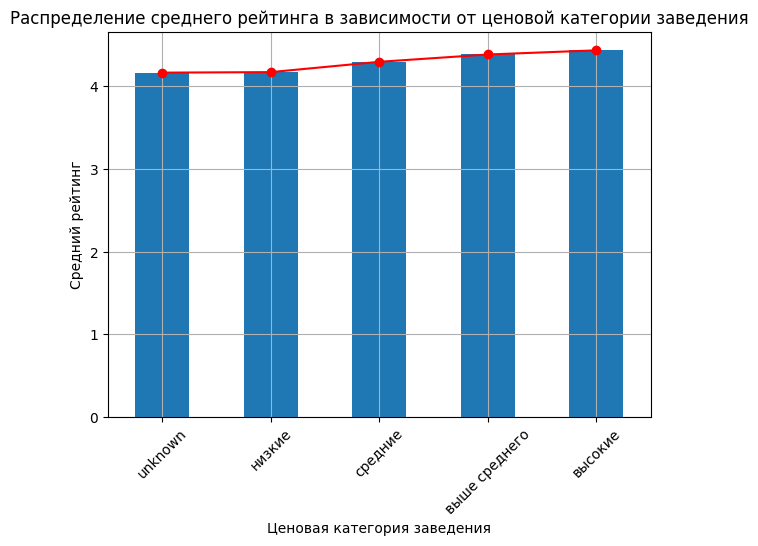

In [ ]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 5))

# Построим график столбчатой диаграммы
grouped = df.groupby('price')['rating'].mean().sort_values()
ax = grouped.plot(kind='bar',
               title=f'Распределение среднего рейтинга в зависимости от ценовой категории заведения',
               ylabel='Средний рейтинг',
               xlabel='Ценовая категория заведения',
               rot=45
)
ax.plot(grouped, marker='o', color='red')

# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

По результатам исследования корреляции рейтинга с другими параметрами заведений можно сделать следующий вывод:


*   Наибольшая корреляция рейтинга заведения наблюдается с ценовой категорией (0.28). Проверка этой связи показала, что коэффициент корреляции положителен, то есть с ростом цен (от категории "низкие" до "высокие") растет и средний рейтинг.
*   Такую корреляцию можно объяснить тем, что в заведениях с ростом ценовой категорией повышается и сервис, качество блюд, интерьер заведения, что напрямую влияет на рейтинг, основанный на оценках посетителей.



---

### Задача 7

Сгруппируем данные по названиям заведений и найдем топ-15 популярных сетей (под популярностью понимается количество заведений этой сети в регионе) в Москве. Для них посчитаем значения среднего рейтинга. Определим, к какой категории заведений они относятся.

In [ ]:
# Сформируем датафрейм с топ-15 заведениями
chain_grouped = df[df['chain'] == 1].groupby(['name']).agg(total_count=('id', 'count'), mean_rating=('rating', 'mean'))
chain_grouped = chain_grouped.reset_index()
chain_top = chain_grouped.sort_values(by='total_count', ascending=False).head(15)
chain_top

,name,total_count,mean_rating
729,шоколадница,120,4.177500
335,домино'с пицца,76,4.169737
331,додо пицца,74,4.286486
146,one price coffee,71,4.064789
742,яндекс лавка,69,3.872464
58,cofix,65,4.075385
168,prime,50,4.116000
664,хинкальная,44,4.322727
409,кофепорт,42,4.147619
418,кулинарная лавка братьев караваевых,39,4.394872


<Figure size 1000x700 with 0 Axes>

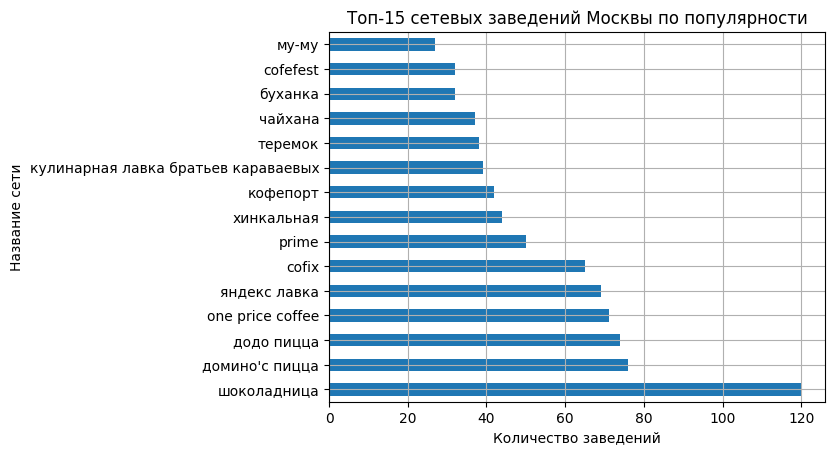

In [ ]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 7))

# Построим график столбчатой диаграммы
chain_top.plot.barh(x='name',
                    y='total_count',
                    title=f'Топ-15 сетевых заведений Москвы по популярности',
                    ylabel='Название сети',
                    xlabel='Количество заведений',
                    rot=0,
                    legend=False
)

# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

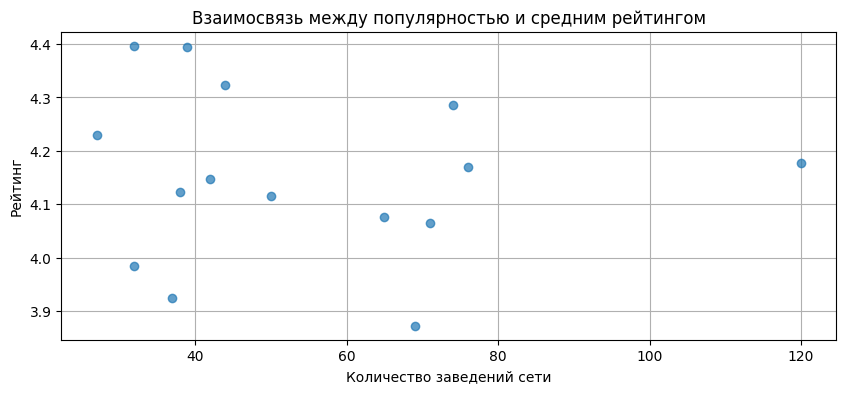

In [ ]:
# Создаём контейнер графика
plt.figure(figsize=(10, 4))

# Строим линейный график
plt.plot(chain_top['total_count'],
         chain_top['mean_rating'],
         marker='o', # Задаём стиль маркера
         linestyle='', # Делаем линии между точками невидимыми
         alpha=0.7)

# Добавляем заголовок и метки осей
plt.title('Взаимосвязь между популярностью и средним рейтингом')
plt.xlabel('Количество заведений сети')
plt.ylabel('Рейтинг')
plt.grid()

# Отображаем график
plt.show()

По графику можно заметить, что высокий рейтинг чаще встречается у менее популярных заведений из найденного топ-15 заведений по популярности. Так, самый высокий рейтинг пренадлежит сети с менее, чем 35 заведениями. Однако низкий рейтинг встречается и у менее популярных заведений, поэтому взаимосвязь нельзя назвать однозначной.

Перед тем, как определить, к каким категориям относятся заведения из топа, необходимо уточнить, что изначальная группировка проводилась только по названию, а значит у заведений сети нет однозначно определенной категории. Например, заведение "Шоколадница" включает в себя сразу 2 категории. Таким образом, для определения основной категории заведения будем рассматривать ту категорию, которая встречается чаще остальных.

In [ ]:
# Категории сетевого заведения "Кафе"
df[df['name'] == 'шоколадница']['category'].unique()

array(['кофейня', 'кафе'], dtype=object)

In [ ]:
# Функция для создания столбца с самой частой категорией
def get_main_category(name):
    categories = name_category_grouped[name_category_grouped['name'] == name]
    if len(categories) == 0:
        return 'неизвестно'
    return categories.loc[categories['count'].idxmax(), 'category']

# Группируем датафрейм по названию и категории
name_category_grouped = df.groupby(['name', 'category']).size().reset_index(name='count')

# Добавляем новый столбец с категорией
chain_top['main_category'] = chain_top['name'].apply(get_main_category)
chain_top


,name,total_count,mean_rating,main_category
729,шоколадница,120,4.177500,кофейня
335,домино'с пицца,76,4.169737,пиццерия
331,додо пицца,74,4.286486,пиццерия
146,one price coffee,71,4.064789,кофейня
742,яндекс лавка,69,3.872464,ресторан
58,cofix,65,4.075385,кофейня
168,prime,50,4.116000,ресторан
664,хинкальная,44,4.322727,кафе
409,кофепорт,42,4.147619,кофейня
418,кулинарная лавка братьев караваевых,39,4.394872,кафе


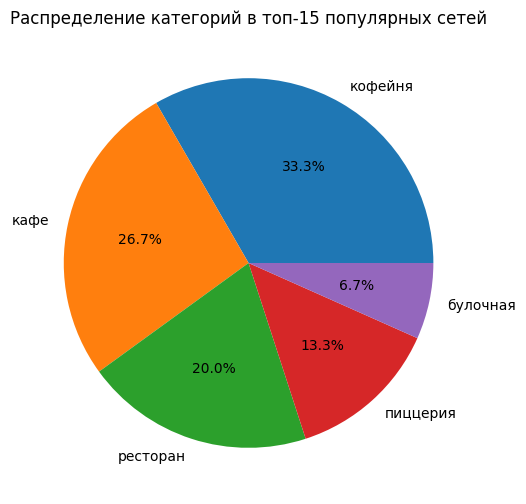

In [ ]:
# Посчитаем количество категорий
category_counts = chain_top['main_category'].value_counts()

# Создаём контейнер графика
plt.figure(figsize=(6, 6))

# Строим круговую диаграмму
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%')

# Добавляем заголовок и метки осей
plt.title('Распределение категорий в топ-15 популярных сетей')
plt.ylabel('')

# Отображаем график
plt.show()

График показывает, что в рамках топ-15 популярных сетевых заведний, категории распределены следующим образом:


*   Кофейня самая многочисленная категория и составляет 33,3% от общего количества заведений в топ-15;
*   Доля кафе - 26,7% от общего количества заведений в топ-15, а доля ресторанов - 20%. Это средние по численности категории.
*   Доля пиццерий - 13,3% от общего количества заведений в топ-15, а доля булочных - 6,7%. Пиццерия в топе встречается дважды, а булочная - 1 раз.


---

### Задача 8

Изучим вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируйем цены в Центральном административном округе и других. Определим, как удалённость от центра влияет на цены в заведениях.


In [ ]:
# Выведем строки с нулем значением чека
df[df['middle_avg_bill'] == 0]

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
3688,502d91289bc5470eabd77fd77cc79821,кофемания,кофейня,"москва, улица новый арбат, 19",центральный административный округ,"ежедневно, круглосуточно",4.5,1,200,высокие,средний счёт:от 0 ₽,0.0,NaN,True


In [ ]:
# Статистические показатели среднего чека заведений
grouped = df[df['middle_avg_bill'] != 0].groupby('district')['middle_avg_bill'].agg(['min', 'max', 'mean', 'median'])
grouped['range'] = grouped['max'] - grouped['min']
grouped

,min,max,mean,median,range
district,,,,,
восточный административный округ,50.0,10000.0,820.626923,575.0,9950.0
западный административный округ,50.0,5250.0,1053.225490,1000.0,5200.0
северный административный округ,130.0,11000.0,927.959627,650.0,10870.0
северо-восточный административный округ,50.0,4500.0,716.611296,500.0,4450.0
северо-западный административный округ,120.0,2900.0,822.222930,700.0,2780.0
центральный административный округ,67.0,7250.0,1192.182247,1000.0,7183.0
юго-восточный административный округ,30.0,3750.0,654.097938,450.0,3720.0
юго-западный административный округ,100.0,2750.0,792.561702,600.0,2650.0
южный административный округ,100.0,35000.0,834.398089,500.0,34900.0


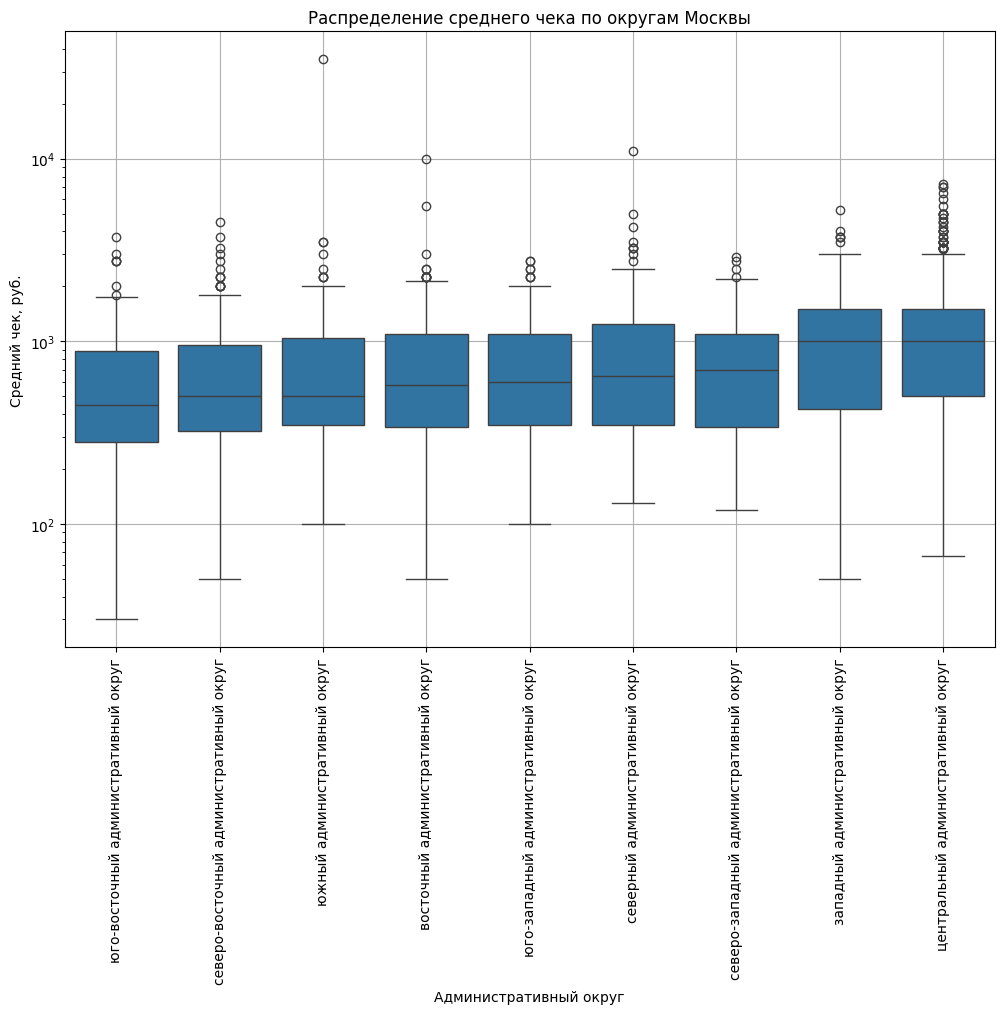

In [ ]:
# Создаём контейнер графика
plt.figure(figsize=(12, 8))

district_order = grouped.sort_values(by='median')

# Строим  диаграмму размаха
sns.boxplot(data=df[df['middle_avg_bill'] != 0], x='district', y='middle_avg_bill', order=district_order.index)

# Добавляем заголовок и метки осей
plt.xticks(rotation=90)
plt.title('Распределение среднего чека по округам Москвы')
plt.xlabel('Административный округ')
plt.ylabel('Средний чек, руб.')
plt.yscale('log')  # если встречаются сильные выбросы

# Добавляем сетку
plt.grid()

# Отображаем график
plt.show()

Распределение среднего чека показывает, что во всех округах встрчаются выбросы. Аномальное значение 35000.00 встрчается в Южном административном округе, которму соответствует и самый большой размах значений. При построении графика были исключены чеки со значением 0, так как такие значения также можно принять за аномальные.

Наибольшее среднее значение по чекам пренадлежит Центральному округу (1192). Медианное значение Центрального округа (1000.0) также совпадает с медианным значением в  Западном округе.

Для того, чтобы определить, как удаленность от центра влияет на ценообразование, каждому административному округу присвоим порядковый номер в зависимости от его расположения относительно центра.

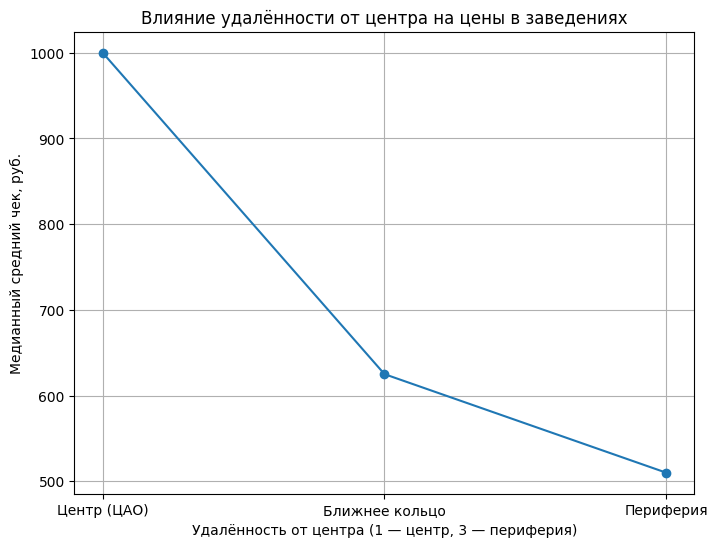

In [ ]:
# Порядок округов от центра к периферии
distance_order = {
    'центральный административный округ': 1,
    'северный административный округ': 2,
    'северо-восточный административный округ': 3,
    'восточный административный округ': 2,
    'юго-восточный административный округ': 3,
    'южный административный округ': 2,
    'юго-западный административный округ': 3,
    'западный административный округ': 2,
    'северо-западный административный округ': 3
}

df['distance_rank'] = df['district'].map(distance_order)

# Группируем по рангу удалённости
dist_grouped = df.groupby('distance_rank')['middle_avg_bill'].agg(['median']).reset_index()

# Создаём контейнер графика
plt.figure(figsize=(8, 6))

# Строим график
plt.plot(dist_grouped['distance_rank'], dist_grouped['median'], marker='o')

# Добавляем заголовок и метки осей
plt.xlabel('Удалённость от центра (1 — центр, 3 — периферия)')
plt.ylabel('Медианный средний чек, руб.')
plt.title('Влияние удалённости от центра на цены в заведениях')
plt.xticks([1, 2, 3], ['Центр (ЦАО)', 'Ближнее кольцо', 'Периферия'])

# Добавляем сетку
plt.grid()

# Отображаем график
plt.show()



По построенрному графику можно сделать вывод о том, что удаленность от центра напряму влияет на величину среднего чека в заведениях. При расчетах использовалось медианное значение среднего чека, так как оно менее чувствительно к выбросам, чем среднее.

---

### Промежуточный вывод

Анализ данных и их взаимосвязипоказал следующее:


*    Наиболее популярная категория "Кафе" включает в себя более 28% завдений Москвы. Следующая по популярности категория - "Ресторан" (24%).
*   Наименее популярные категории по численнояти - "Столовая" и "Булочная", их общая доля от всех заведений составляет менее 10%.
*    Распределение среднего рейтинга в зависимости от категории заведения показывает, что усреднённые рейтинги для разных типов общепита слабо отличаются друг от друга. Все категории обладают оценкой выше 4. Самый высокий усредненный рейтинг пренадлежит категории бар, самый низкий - быстрое питание.
*   Наибольшая корреляция рейтинга заведения наблюдается с ценовой категорией (0.28). Проверка этой связи показала, что коэффициент корреляции положителен, то есть с ростом цен (от категории "низкие" до "высокие") растет и средний рейтинг.
*  Количество несетевых заведений превышает количество сетевых. Их процентное соотношение - 68% и 32%.
*   Категории заведений, где количество сетевых заведений превышает количество несетевых - булочная, пиццерия, кофейня.
*   Категории заведений, где количество несетевых заведений превышает количество сетевых - бар, быстрое питание, ресторан, столовая.
*   Центарльный административный округ содержит в себе наибольшее количество заведений (около 27%). Распределение заведений по другим административным районам Москвы близко к равномерному - на каждый район приходится около 8-10% заведений.
*   Удаленность от центра (Центарльный административный округ) напряму влияет на величину среднего чека в заведениях.



## 4. Итоговый вывод и рекомендации

### Общий обзор проделанной работы
В рамках данного проекта был проведён исследовательский анализ данных о заведениях общественного питания Москвы. Были загружены и объединены два датасета (rest_info.csv и rest_price.csv), содержащих информацию о 8406 заведениях. Выполнена предобработка данных: обработаны пропуски и дубликаты, оптимизированы типы данных, создан новый признак is_24_7 (работает ли заведение круглосуточно).

В ходе анализа были исследованы следующие аспекты:

* распределение заведений по категориям и административным округам;

* соотношение сетевых и несетевых заведений;

* распределение рейтингов и их корреляция с другими признаками;

* распределение количества посадочных мест;

* топ-15 популярных сетей и их категориальный состав;

* влияние удалённости от центра на средний чек.

###Ключевые выводы исследования
**1. Категории заведений**

Наиболее распространённые категории — «кафе» (28,3%) и «ресторан» (24,3%).

Наименее популярны «столовая» (3,7%) и «булочная» (3,0%).

**2. Административные округа**

Центральный административный округ лидирует по количеству заведений — 26,7% от всех. В этом районе преобладают рестораны, в отличие от общего распределения, где лидируют кафе.

Распределение по остальным округам близко к равномерному (по 8–10%).

**3. Сетевые и несетевые заведения**

Несетевых заведений значительно больше (62% vs 38%).

Среди категорий булочные, пиццерии и кофейни чаще являются сетевыми. Наибольшая доля несетевых заведений — среди баров, ресторанов и столовых.

**4. Рейтинги**

Средний рейтинг по всем заведениям — 4,23.

Усреднённые рейтинги по категориям различаются слабо (все выше 4). Самый высокий — у баров, самый низкий — у быстрого питания. Наибольшая корреляция рейтинга наблюдается с ценовой категорией (0,28): чем выше цены, тем выше рейтинг. Корреляция с количеством посадочных мест отсутствует.

**5. Посадочные места**

Медианное количество посадочных мест — 75. Аномальные значения (>300) могут быть связаны с крупными ресторанами и банкетными залами. Больше всего мест — в ресторанах, барах и кофейнях, меньше всего — в булочных.

**6. Топ-15 популярных сетей**

Самая популярная сеть — «Шоколадница» (120 заведений). Среди топ-15 преобладают кофейни (33,3%), кафе (26,7%), рестораны (20%), пиццерии (13,3%), булочные (6,7%).

Высокий рейтинг чаще встречается у менее популярных сетей.

**7. Средний чек и удалённость от центра**

Средний чек в Центральном административном округе значительно выше (медиана — 1000 руб.), чем в других округах. Прослеживается чёткий тренд: удалённость от центра приводит к снижению медианного чека.

### Рекомендации на основе анализа
* Для развития сетевых проектов:

Рекомендуется обратить внимание на категории булочные, пиццерии и кофейни — они показывают наибольшую склонность к сетевизации и стабильный спрос.

* Для повышения рейтинга:

Инвестиции в повышение качества обслуживания и уровня цен коррелируют с ростом оценок пользователей.

* Для открытия новых точек:

Наиболее перспективные районы — с высокой плотностью заведений, но при этом с более низким средним чеком (например, Юго-Восточный и Северо-Восточный округа).

* Для сетей из топ-15:

Сетям с низким рейтингом рекомендуется провести аудит качества обслуживания и проанализировать отзывы для выявления системных проблем.

* Для анализа ценовой политики:

В Центральном административном округе можно устанавливать более высокие цены без потери рейтинга, на периферии - делать акцент на доступность.